<a href="https://colab.research.google.com/github/nicholastimmann-cyber/Travel_Tide_CustomerSegmentation/blob/main/preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Importing of important packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


In [2]:
# Mounting of Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
directory = "/content/drive/MyDrive/Colab Notebooks"

session_name = "session_base.csv"

df_session = pd.read_csv(f'{directory}/Mastery_project_CSVclean.csv')



In [4]:
# Converts the specified columns to datetime format and calculates each session’s duration in seconds by subtracting session_start from session_end.
datetime_cols = ['session_start', 'session_end', 'departure_time', 'return_time']

for col in datetime_cols:
    df_session[col] = pd.to_datetime(df_session[col], format='mixed')

df_session['session_duration'] = (df_session['session_end'] - df_session['session_start']).dt.total_seconds()

In [5]:
# Confirming if it worked
df_session.describe()

,user_id,session_start,session_end,page_clicks,flight_discount_amount,hotel_discount_amount,home_airport_lat,home_airport_lon,seats,departure_time,return_time,checked_bags,destination_airport_lat,destination_airport_lon,base_fare_usd,nights,rooms,hotel_price_per_room_night_usd,session_duration
count,49211.000000,49211,49211,49211.000000,8282.000000,6205.000000,49211.000000,49211.000000,14270.000000,14270,13652,14270.000000,14270.000000,14270.000000,14270.000000,14726.000000,14726.000000,14726.000000,49211.000000
mean,545282.694946,2023-03-21 11:25:24.870191616,2023-03-21 11:28:32.122520320,17.588791,0.139864,0.112192,38.427222,-94.183762,1.215207,2023-04-15 17:07:40.154169600,2023-04-20 02:07:30.659244032,0.592922,38.610024,-88.947203,525.901390,3.672484,1.194554,177.937390,187.252329
min,23557.000000,2023-01-04 00:01:00,2023-01-04 00:04:23,1.000000,0.050000,0.050000,21.316000,-157.927000,1.000000,2023-01-07 07:00:00,2023-01-08 07:00:00,0.000000,-37.008000,-157.927000,2.410000,-2.000000,1.000000,17.000000,6.000000
25%,517119.000000,2023-02-05 22:31:30,2023-02-05 22:34:10.500000,6.000000,0.100000,0.050000,33.818000,-112.383000,1.000000,2023-02-15 15:00:00,2023-02-19 13:00:00,0.000000,33.942000,-112.383000,200.432500,1.000000,1.000000,99.000000,45.000000
50%,540308.000000,2023-03-09 11:04:00,2023-03-09 11:06:35,13.000000,0.100000,0.100000,39.103000,-90.035000,1.000000,2023-03-23 16:00:00,2023-03-27 10:00:00,1.000000,39.872000,-87.752000,381.765000,2.000000,1.000000,148.000000,96.000000
75%,573922.000000,2023-04-28 11:23:00,2023-04-28 11:25:11.500000,22.000000,0.200000,0.150000,42.238000,-79.370000,1.000000,2023-05-23 14:45:00,2023-05-27 12:15:00,1.000000,42.409000,-75.241000,600.632500,5.000000,1.000000,222.000000,162.000000
max,844489.000000,2023-07-28 19:58:52,2023-07-28 20:08:52,566.000000,0.600000,0.450000,61.251000,-63.499000,8.000000,2024-07-16 07:00:00,2024-07-30 16:00:00,8.000000,55.972000,174.792000,21548.040000,43.000000,4.000000,1376.000000,7200.000000
std,64640.047648,NaN,NaN,21.495987,0.083914,0.062119,6.185962,18.065868,0.585891,NaN,NaN,0.677641,6.949739,33.090373,818.296468,3.806717,0.499344,118.334569,660.250156


In [6]:
df_session.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49211 entries, 0 to 49210
Data columns (total 42 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   session_id                      49211 non-null  object        
 1   user_id                         49211 non-null  int64         
 2   trip_id                         16702 non-null  object        
 3   session_start                   49211 non-null  datetime64[ns]
 4   session_end                     49211 non-null  datetime64[ns]
 5   page_clicks                     49211 non-null  int64         
 6   flight_discount                 49211 non-null  bool          
 7   flight_discount_amount          8282 non-null   float64       
 8   hotel_discount                  49211 non-null  bool          
 9   hotel_discount_amount           6205 non-null   float64       
 10  flight_booked                   49211 non-null  bool          
 11  ho

In [7]:
# Looking for Null values
print(df_session.columns)
print(df_session.shape)
#print(df_session.dtypes)
print(df_session.isnull().sum())

Index(['session_id', 'user_id', 'trip_id', 'session_start', 'session_end',
       'page_clicks', 'flight_discount', 'flight_discount_amount',
       'hotel_discount', 'hotel_discount_amount', 'flight_booked',
       'hotel_booked', 'cancellation', 'birthdate', 'gender', 'married',
       'has_children', 'home_country', 'home_city', 'home_airport',
       'home_airport_lat', 'home_airport_lon', 'sign_up_date',
       'origin_airport', 'destination', 'destination_airport', 'seats',
       'return_flight_booked', 'departure_time', 'return_time', 'checked_bags',
       'trip_airline', 'destination_airport_lat', 'destination_airport_lon',
       'base_fare_usd', 'hotel_name', 'nights', 'rooms', 'check_in_time',
       'check_out_time', 'hotel_price_per_room_night_usd', 'session_duration'],
      dtype='object')
(49211, 42)
session_id                            0
user_id                               0
trip_id                           32509
session_start                         0
session_en

In [8]:
#Looking at descriptives of the Data
df_session.describe().T

,count,mean,min,25%,50%,75%,max,std
user_id,49211.0,545282.694946,23557.0,517119.0,540308.0,573922.0,844489.0,64640.047648
session_start,49211,2023-03-21 11:25:24.870191616,2023-01-04 00:01:00,2023-02-05 22:31:30,2023-03-09 11:04:00,2023-04-28 11:23:00,2023-07-28 19:58:52,NaN
session_end,49211,2023-03-21 11:28:32.122520320,2023-01-04 00:04:23,2023-02-05 22:34:10.500000,2023-03-09 11:06:35,2023-04-28 11:25:11.500000,2023-07-28 20:08:52,NaN
page_clicks,49211.0,17.588791,1.0,6.0,13.0,22.0,566.0,21.495987
flight_discount_amount,8282.0,0.139864,0.05,0.1,0.1,0.2,0.6,0.083914
hotel_discount_amount,6205.0,0.112192,0.05,0.05,0.1,0.15,0.45,0.062119
home_airport_lat,49211.0,38.427222,21.316,33.818,39.103,42.238,61.251,6.185962
home_airport_lon,49211.0,-94.183762,-157.927,-112.383,-90.035,-79.37,-63.499,18.065868
seats,14270.0,1.215207,1.0,1.0,1.0,1.0,8.0,0.585891
departure_time,14270,2023-04-15 17:07:40.154169600,2023-01-07 07:00:00,2023-02-15 15:00:00,2023-03-23 16:00:00,2023-05-23 14:45:00,2024-07-16 07:00:00,NaN


In [9]:
# Look for zero or negative values in the 'nights' column.
# These typically occur when the check-in time is after the check-out time,
# which may be caused by data entry errors, timezone inconsistencies,
# incorrect date parsing (e.g. mixed formats), same-day stays,
# logging order issues, or mismatches during dataset merges.
df_session[df_session['nights'] <= 0][['trip_id', 'check_in_time', 'check_out_time', 'nights']].head(2)

,trip_id,check_in_time,check_out_time,nights
2672,665593-258e19907f8f40f08a502f8754990d5c,2023-07-07 14:11:49.38,2023-07-07 11:00:00,-1.0
3001,500974-8e81ae6ba3544ed6bf519a342f5ac9b8,2023-01-26 14:01:28.335,2023-01-27 11:00:00,0.0


In [10]:
# Filter sessions with 100 or more page clicks to inspect high-engagement or potentially anomalous user behavior.
df_session[df_session['page_clicks'] >= 100][['user_id', 'trip_id', 'hotel_booked', 'flight_booked', 'session_duration', 'page_clicks']]

,user_id,trip_id,hotel_booked,flight_booked,session_duration,page_clicks
111,558270,NaN,False,False,1804.0,243
543,626520,NaN,False,False,792.0,107
980,525176,NaN,False,False,797.0,108
1117,499780,NaN,False,False,1933.0,262
1450,567651,NaN,False,False,1933.0,261
...,...,...,...,...,...,...
49150,486751,486751-ac8269b44cf44e37a344c955f34f6146,True,True,7200.0,200
49171,565565,565565-5fcbfd8953e14ddeb5b4d17878327b11,True,True,7200.0,200
49181,565565,565565-5fcbfd8953e14ddeb5b4d17878327b11,True,False,906.0,122
49192,542095,542095-da1172e2431342eba39c1630cbf81673,True,True,895.0,121


In [11]:
# Creating of a Boxplot to look for outliers in session duration
def plot_distribution(df, column_name):
  """
  Plots a boxplot and a histogram for a given column in a DataFrame.

  Args:
    df: The pandas DataFrame.
    column_name: The name of the column to visualize.
  """
  fig, axes = plt.subplots(1, 2, figsize=(12, 6))

  # Boxplot
  sns.boxplot(y=df[column_name], ax=axes[0])
  axes[0].set_title(f'Boxplot of {column_name}')

  # Histogram
  sns.histplot(df[column_name], ax=axes[1], kde=True)
  axes[1].set_title(f'Histogram of {column_name}')

  plt.tight_layout()
  plt.show()

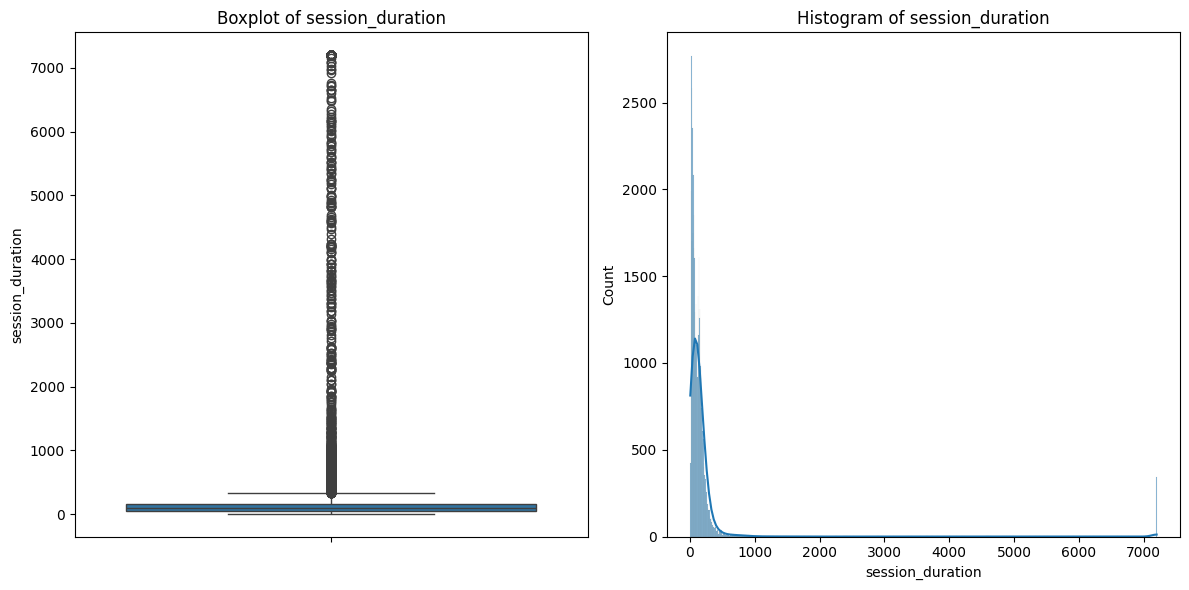

In [12]:
plot_distribution(df_session, 'session_duration')

In [13]:
#Removeal of outliers with a to high session duration as these are most likley bots or other outliers
def remove_outliers_iqr(df, column_name):
  """
  Removes outliers from a specified column in a DataFrame using the IQR method.

  Args:
    df: The pandas DataFrame.
    column_name: The name of the column to remove outliers from.

  Returns:
    A new DataFrame with outliers removed.
  """
  Q1 = df[column_name].quantile(0.25)
  Q3 = df[column_name].quantile(0.75)
  IQR = Q3 - Q1

  lower_bound = Q1 - 5 * IQR
  upper_bound = Q3 + 5 * IQR

  original_rows = df.shape[0]
  df_cleaned = df[(df[column_name] >= lower_bound) & (df[column_name] <= upper_bound)].copy()
  removed_rows = original_rows - df_cleaned.shape[0]

  print(f"Removed {removed_rows} outliers from the '{column_name}' column.")

  return df_cleaned

Removed 831 outliers from the 'session_duration' column.


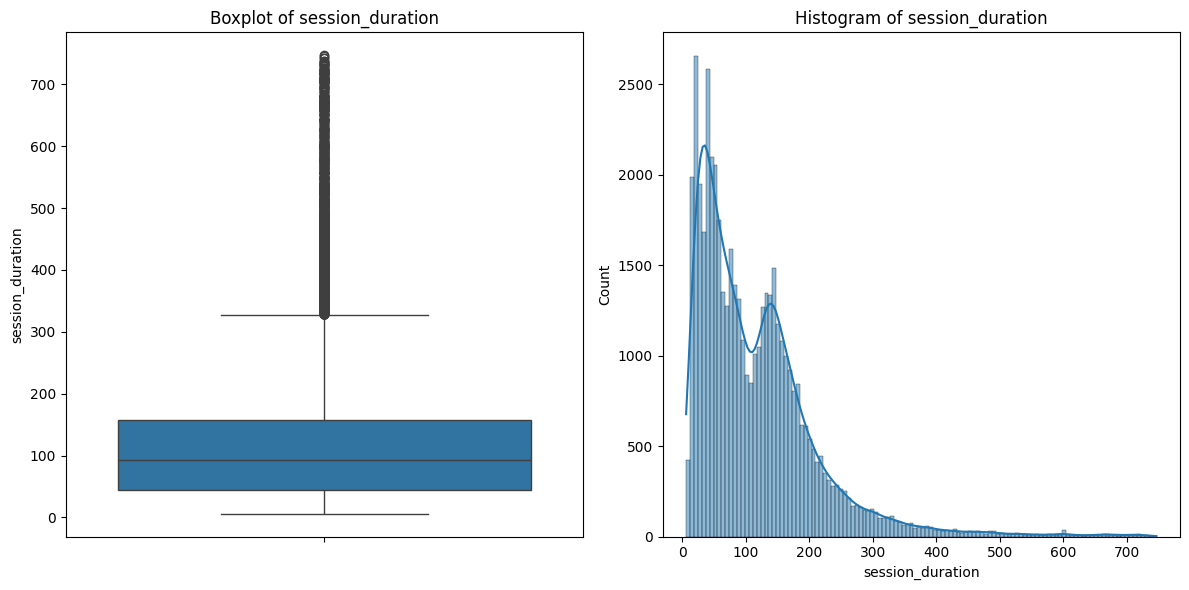

In [14]:
df_cleaned = remove_outliers_iqr(df_session, 'session_duration')
plot_distribution(df_cleaned, 'session_duration')

Statt die Ausreißer zu löschen können wir uns überlegen Unter-und Obergrenzen festzusetzen und dann zu clippen

In [15]:
def clip_outliers_iqr(df, column_name):
  """
  Removes outliers from a specified column in a DataFrame using the IQR method.

  Args:
    df: The pandas DataFrame.
    column_name: The name of the column to remove outliers from.

  Returns:
    A new DataFrame with outliers removed.
  """
  Q1 = df[column_name].quantile(0.25)
  Q3 = df[column_name].quantile(0.75)
  IQR = Q3 - Q1

  lower_bound = Q1 - 5 * IQR
  upper_bound = Q3 + 5 * IQR
  df_cliped = df.copy()
  df_cliped[column_name] = df_cliped[column_name].clip(lower_bound, upper_bound)

  return df_cliped

In [16]:
#clip outliers
df_session_clip = clip_outliers_iqr(df_session, "page_clicks")
df_session_clip = clip_outliers_iqr(df_session_clip, "session_duration")
#remove outliers
df_session_rm = remove_outliers_iqr(df_session, "page_clicks")
df_session_rm = remove_outliers_iqr(df_session_rm, "session_duration")

Removed 605 outliers from the 'page_clicks' column.
Removed 241 outliers from the 'session_duration' column.


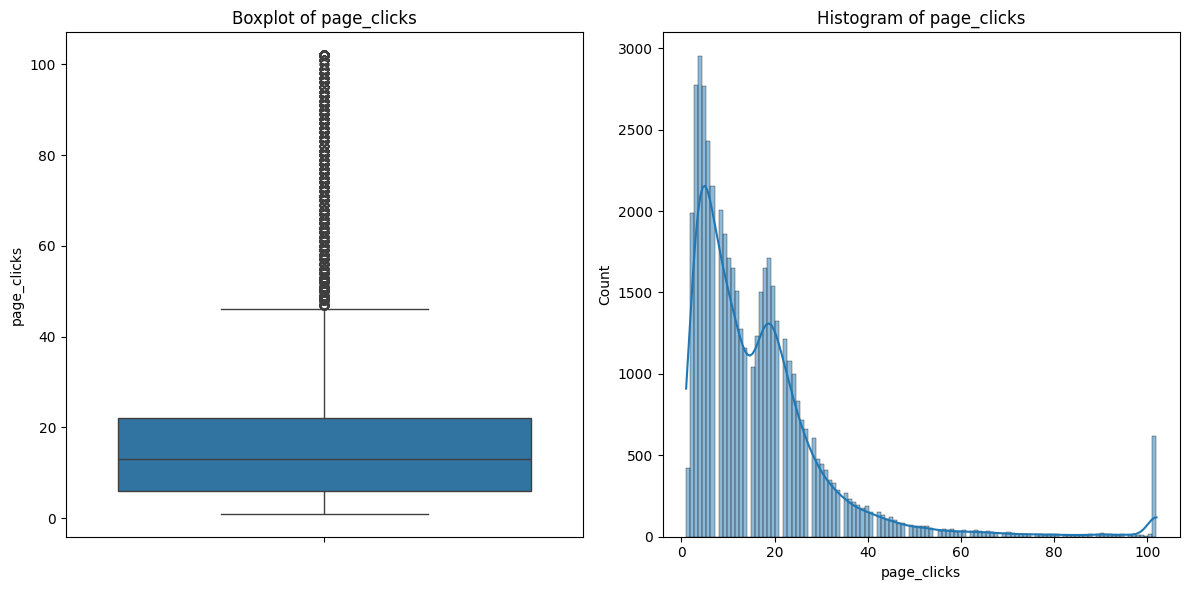

In [17]:
plot_distribution(df_session_clip, 'page_clicks')

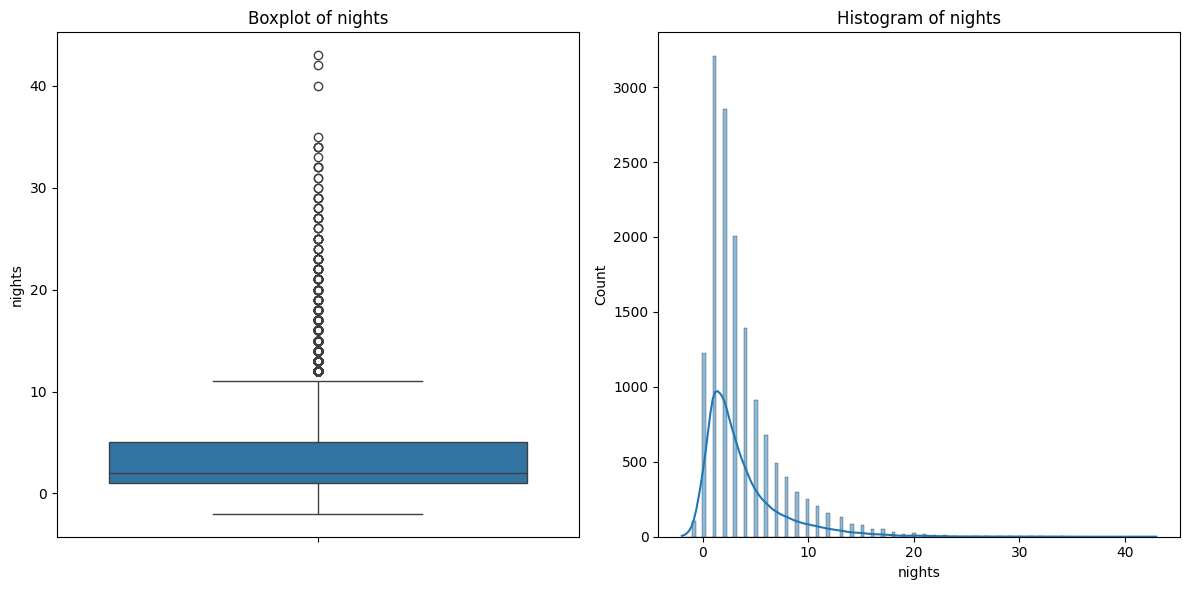

In [18]:
plot_distribution(df_session, "nights")

In [19]:
#plot_distribution(df_session_clip, "nights")

#print out negative nights
df_session[df_session['check_out_time'] < df_session['check_in_time']][['user_id', 'nights', 'check_in_time', 'check_out_time', 'departure_time', 'return_time', 'hotel_price_per_room_night_usd']]

,user_id,nights,check_in_time,check_out_time,departure_time,return_time,hotel_price_per_room_night_usd
2672,665593,-1.0,2023-07-07 14:11:49.38,2023-07-07 11:00:00,2023-07-07 09:00:00,2023-07-08 09:00:00,122.0
23445,476714,0.0,2023-01-15 11:44:13.425,2023-01-15 11:00:00,2023-01-15 08:00:00,2023-01-16 08:00:00,294.0
32764,562886,-1.0,2023-02-05 12:40:44.535,2023-02-05 11:00:00,2023-02-05 10:00:00,2023-02-06 10:00:00,127.0
32830,372970,-1.0,2023-03-12 13:34:49.935,2023-03-12 11:00:00,2023-03-12 07:00:00,2023-03-13 07:00:00,132.0
32854,552363,0.0,2023-05-13 11:39:07.875,2023-05-13 11:00:00,2023-05-13 07:00:00,2023-05-15 07:00:00,179.0
...,...,...,...,...,...,...,...
48851,517732,-1.0,2023-01-19 13:52:45.84,2023-01-19 11:00:00,2023-01-19 07:00:00,2023-01-20 07:00:00,158.0
48897,663376,0.0,2023-06-14 11:00:27.36,2023-06-14 11:00:00,2023-06-14 07:00:00,2023-06-15 07:00:00,144.0
49120,510093,0.0,2023-07-30 11:45:27.81,2023-07-30 11:00:00,2023-07-30 07:00:00,2023-07-31 07:00:00,109.0
49136,665329,-1.0,2023-07-04 14:57:38.25,2023-07-04 11:00:00,2023-07-04 12:00:00,2023-07-05 12:00:00,91.0


In [20]:
# Replace zero or negative values in the 'nights' column with 1 to enforce a minimum stay of one night.
df_session_clip['nights'] = df_session_clip['nights'].apply(lambda x: 1 if x <= 0 else x)

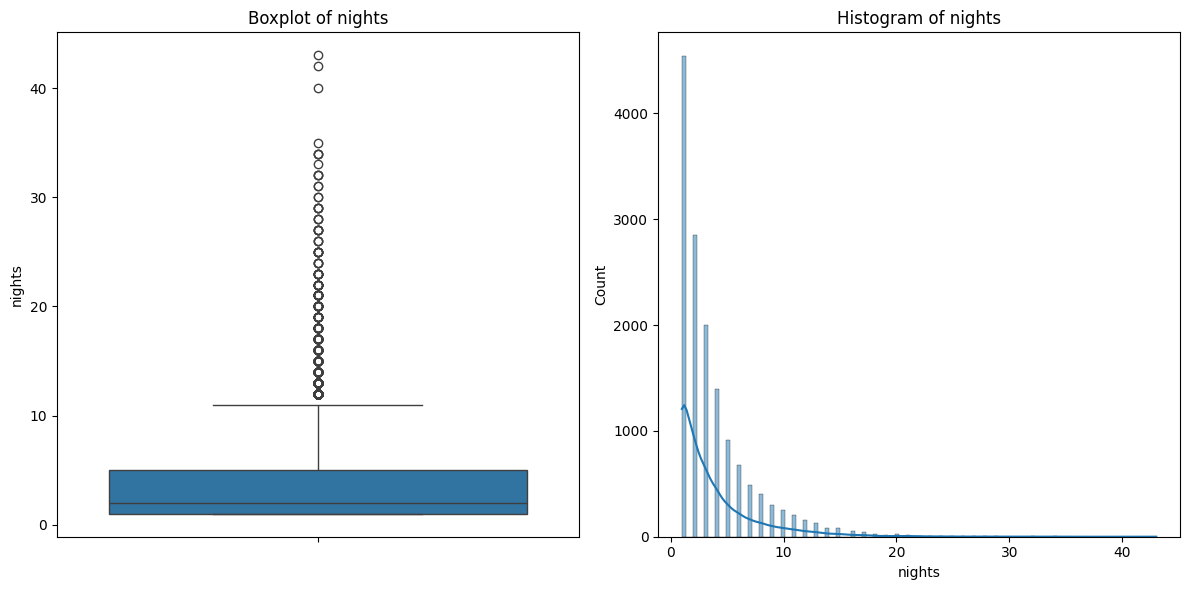

In [21]:
plot_distribution(df_session_clip, "nights")

In [22]:
#Save a
df_session_clip.to_csv(f'{directory}/session_base_cleaned.csv', index=False)